In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from features_v2 import build_feature_matrix
from model_v2 import (
    temporal_split, train_val_split, prepare_Xy, get_feature_cols,
    compute_pos_weight, build_models, cross_validate_models,
    train_base_model, optuna_tune, calibrate,
    tune_threshold_operational, evaluate,
    per_module_metrics, shap_analysis, shap_waterfall, build_alerts
)

os.makedirs('OUTPUTS', exist_ok=True)
os.makedirs('PLOTS',   exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Setup complete.')

C:\Users\asyed\OneDrive\Desktop\Studor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## Stage 1 — Build Feature Matrix

In [2]:
df = build_feature_matrix(data_dir='..')
feat_cols = get_feature_cols(df)
print(f'\nTotal students: {len(df):,}')
print(f'Features: {len(feat_cols)}')
print(f'Label rate: {df["label"].mean():.3f}')

Loading CSVs...


Done.


Feature matrix: 32,593 students, 40 features
Label distribution:
label
1    17208
0    15385
Name: count, dtype: int64

Feature columns (40):
  mean_score_w6
  min_score_w6
  std_score_w6
  weeks_below_40
  weeks_present
  score_slope_w6
  score_at_w6
  mean_days_active_w6
  mean_activity_diversity_w6
  total_clicks_w6
  completion_rate_w6
  any_submission_w6
  mean_score_ass_w6
  mean_timeliness_w6
  imd_band_num
  age_band_num
  gender_F
  disability_Y
  num_of_prev_attempts
  studied_credits
  early_registrant
  reg_days_before
  mod_AAA
  mod_BBB
  mod_CCC
  mod_DDD
  mod_EEE
  mod_FFF
  mod_GGG
  arch_w6_Anxious
  arch_w6_Coasting
  arch_w6_Early Dropout
  arch_w6_Ghost
  arch_w6_Recovering
  arch_w6_Steady Engager
  arch_w6_Struggling
  arch_w6_Early_Dropout
  arch_w6_Steady_Engager
  n_archetype_changes_w6
  transition_dir_num

Total students: 32,593
Features: 40
Label rate: 0.528


## Stage 2 — Temporal Train / Test Split

Train on 2013 presentations, test on 2014 presentations.
Simulates real deployment: model trained on historical cohorts, predicting future cohorts.
v1 used random stratified split which mixed years and inflated AUROC.

In [3]:
df_train_full, df_test = temporal_split(df)

# 75% base model training / 25% validation
# Validation used for: threshold tuning + Platt calibration — never seen by base model
df_train, df_val = train_val_split(df_train_full, val_size=0.25)

X_tr,  y_tr  = prepare_Xy(df_train, feat_cols)
X_val, y_val = prepare_Xy(df_val,   feat_cols)
X_te,  y_te  = prepare_Xy(df_test,  feat_cols)

print(f'\nThree-way split:')
print(f'  Base model train : {len(X_tr):,}  (label rate {y_tr.mean():.3f})')
print(f'  Validation       : {len(X_val):,}  (label rate {y_val.mean():.3f})')
print(f'  Test             : {len(X_te):,}  (label rate {y_te.mean():.3f})')

Temporal split:
  Train (2013J, 2013B): 13,529 students
  Test  (2014J, 2014B): 19,064 students
  Train label rate: 0.514
  Test  label rate: 0.538

Three-way split:
  Base model train : 10,146  (label rate 0.514)
  Validation       : 3,383  (label rate 0.514)
  Test             : 19,064  (label rate 0.538)


## Stage 3 — Cross-Validation Comparison

Consistent `scale_pos_weight` across all models — v1 used weight=1 in CV but computed
the correct weight only for the final model, making the comparison unfair.

In [4]:
pos_weight = compute_pos_weight(y_tr)
print(f'Class imbalance ratio (neg/pos): {pos_weight:.3f}')

models = build_models(pos_weight)
print('\n5-fold stratified CV on training set:')
cv_results = cross_validate_models(models, X_tr, y_tr)

Class imbalance ratio (neg/pos): 0.944

5-fold stratified CV on training set:


Logistic Regression        AUROC=0.872±0.007  Recall=0.704±0.007


Random Forest              AUROC=0.868±0.007  Recall=0.728±0.009


XGBoost                    AUROC=0.866±0.007  Recall=0.726±0.006


## Stage 4 — Optuna Hyperparameter Tuning

**Why tune AUROC (not Recall directly):**
AUROC is threshold-independent — it measures how well the model ranks at-risk students
above safe ones regardless of the decision line. Optimising Recall directly would just
push the model to flag everyone (trivially Recall = 1.0 if threshold = 0). A better
AUROC means higher Recall is achievable at any given flag rate.

**Why Optuna (TPE) over grid search:**
Grid search evaluates all combinations — exponential in parameters. Optuna uses
Tree-structured Parzen Estimator: it builds a probabilistic model of which regions
of the search space produce good results, then samples from promising regions.
80 trials finds better configs than a brute-force grid, in a fraction of the time.

**Why 50% flag rate ceiling (raised from 35%):**
At 35% ceiling, threshold=0.725 gave Recall=0.643. The tier system (High/Medium/Watch)
within the flagged pool lets advisors prioritise — so 50% is operationally viable:
advisors act on High immediately, schedule Medium check-ins, monitor Watch passively.

  0%|          | 0/80 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.860915:   0%|          | 0/80 [00:02<?, ?it/s]

Best trial: 0. Best value: 0.860915:   1%|▏         | 1/80 [00:02<03:28,  2.64s/it]

Best trial: 1. Best value: 0.874559:   1%|▏         | 1/80 [00:07<03:28,  2.64s/it]

Best trial: 1. Best value: 0.874559:   2%|▎         | 2/80 [00:07<05:22,  4.14s/it]

...

Best trial: 64. Best value: 0.875305: 100%|██████████| 80/80 [03:39<00:00,  2.41s/it]

Best trial: 64. Best value: 0.875305: 100%|██████████| 80/80 [03:39<00:00,  2.74s/it]


Optuna best CV AUROC : 0.8753  (over 80 trials)
Best hyperparameters:
  n_estimators        : 699
  learning_rate       : 0.016072582517400815
  max_depth           : 4
  min_child_weight    : 2
  subsample           : 0.7044428457329472
  colsample_bytree    : 0.5433182312841714
  gamma               : 2.0098857540432067
  reg_alpha           : 3.4696577162018394
  reg_lambda          : 5.005071097297702


Val set AUROC (tuned model): 0.8671


C:\Users\asyed\AppData\Local\Temp\ipykernel_36816\3518422750.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


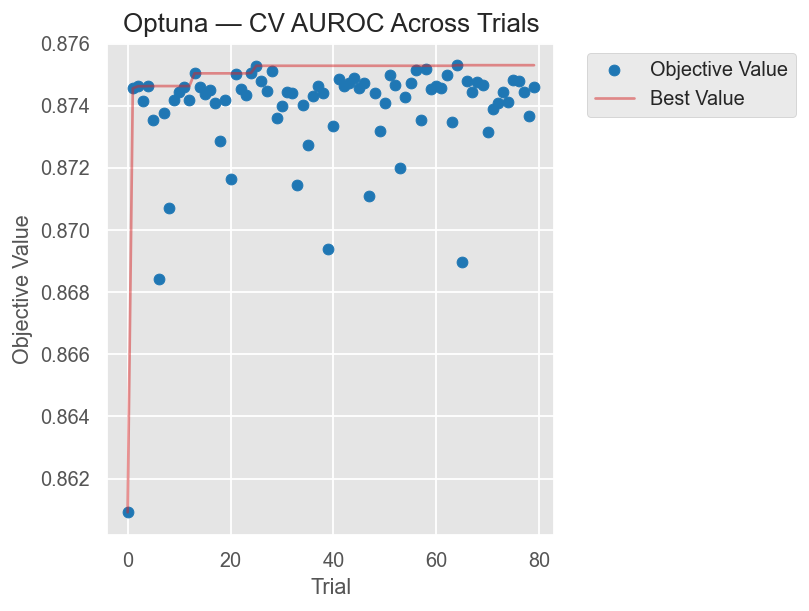

Saved: PLOTS/optuna_history.png


In [5]:
tuned_model, best_params, study = optuna_tune(X_tr, y_tr, X_val, y_val, n_trials=80)

fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna — CV AUROC Across Trials')
plt.tight_layout()
plt.savefig('PLOTS/optuna_history.png', bbox_inches='tight')
plt.show()
print('Saved: PLOTS/optuna_history.png')

## Stage 5 — Calibration on Validation Set

Platt scaling fit on held-out validation set (never seen by tuned model during training).

In [6]:
cal_model = calibrate(tuned_model, X_val, y_val)
from sklearn.metrics import roc_auc_score
cal_auroc = roc_auc_score(y_val, cal_model.predict_proba(X_val)[:, 1])
print(f'Calibrated tuned model AUROC on val set: {cal_auroc:.4f}')

Calibrated tuned model AUROC on val set: 0.8671


## Stage 6 — Threshold Tuning on Validation Set (50% ceiling)

Operational constraint: flag rate <= 50% of cohort.
Maximise Recall within that ceiling.
Threshold chosen on val set only — test set untouched until Stage 7.


Operational threshold selection (val set, flag_rate_ceiling=50%):
  Best threshold : 0.435
  Flag rate      : 0.497 (49.7% of students)
  Recall         : 0.7661
  Precision      : 0.7920
  F1             : 0.7788


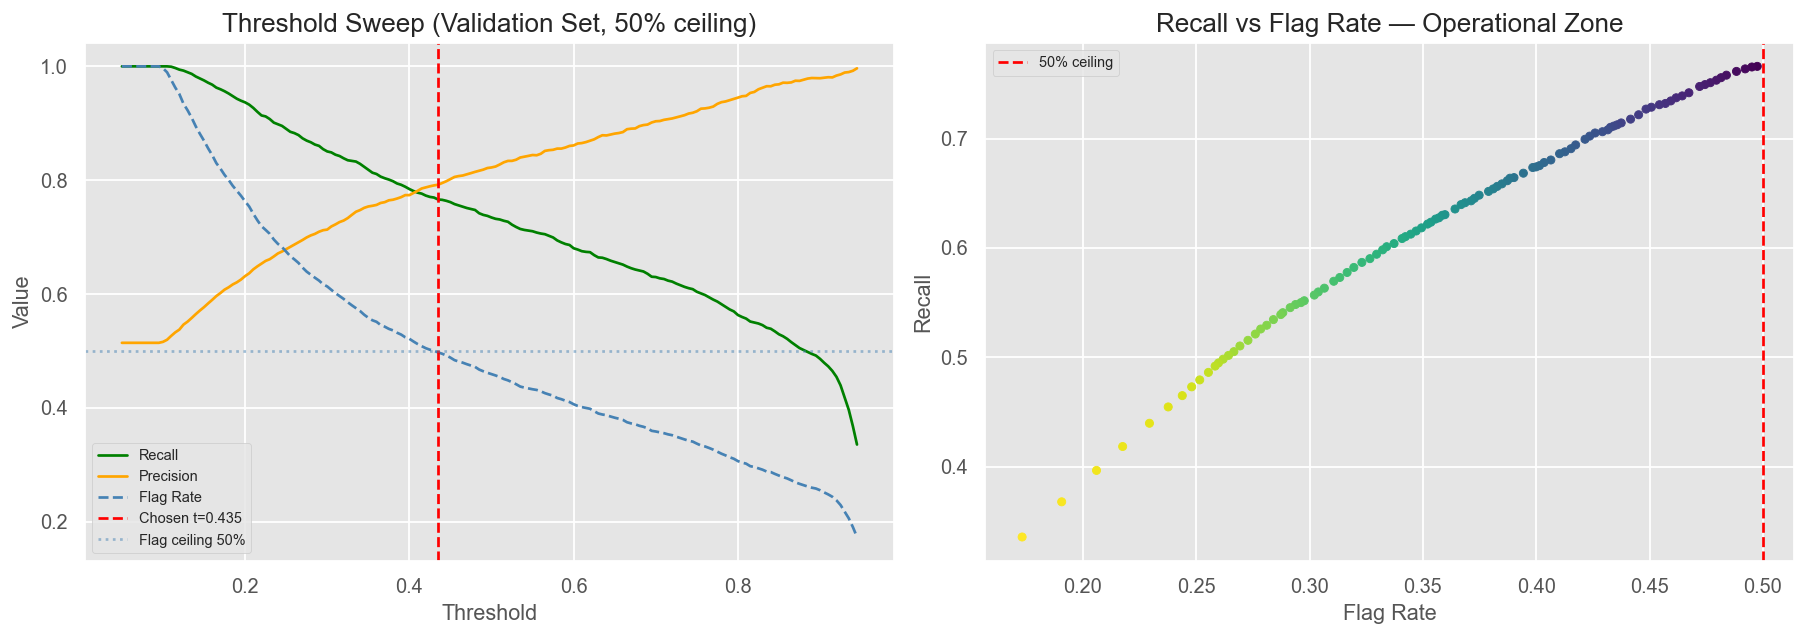

Saved: PLOTS/threshold_operational.png


In [7]:
best_threshold, sweep = tune_threshold_operational(cal_model, X_val, y_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sweep['threshold'], sweep['recall'],    label='Recall',    color='green')
ax.plot(sweep['threshold'], sweep['precision'], label='Precision', color='orange')
ax.plot(sweep['threshold'], sweep['flag_rate'], label='Flag Rate', color='steelblue', linestyle='--')
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Chosen t={best_threshold:.3f}')
ax.axhline(0.50, color='steelblue', linestyle=':', alpha=0.5, label='Flag ceiling 50%')
ax.set_xlabel('Threshold'); ax.set_ylabel('Value')
ax.set_title('Threshold Sweep (Validation Set, 50% ceiling)')
ax.legend(fontsize=8)

ax2 = axes[1]
valid = sweep[sweep['flag_rate'] <= 0.50]
ax2.scatter(valid['flag_rate'], valid['recall'], c=valid['threshold'], cmap='viridis', s=20)
ax2.axvline(0.50, color='red', linestyle='--', label='50% ceiling')
ax2.set_xlabel('Flag Rate'); ax2.set_ylabel('Recall')
ax2.set_title('Recall vs Flag Rate — Operational Zone')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('PLOTS/threshold_operational.png', bbox_inches='tight')
plt.show()
print('Saved: PLOTS/threshold_operational.png')

## Stage 7 — Final Evaluation on Test Set

Test set is untouched until this point — no tuning, no calibration, no threshold selection
used it. All reported metrics are honest out-of-sample estimates.


XGBoost (calibrated, tuned) — Test Set Results @ threshold=0.435
  AUROC       : 0.8498
  Recall      : 0.7780
  Precision   : 0.7775
  F1          : 0.7778
  F2          : 0.7779
  Brier       : 0.1624
  Flag Rate   : 0.5380
  Threshold   : 0.4350


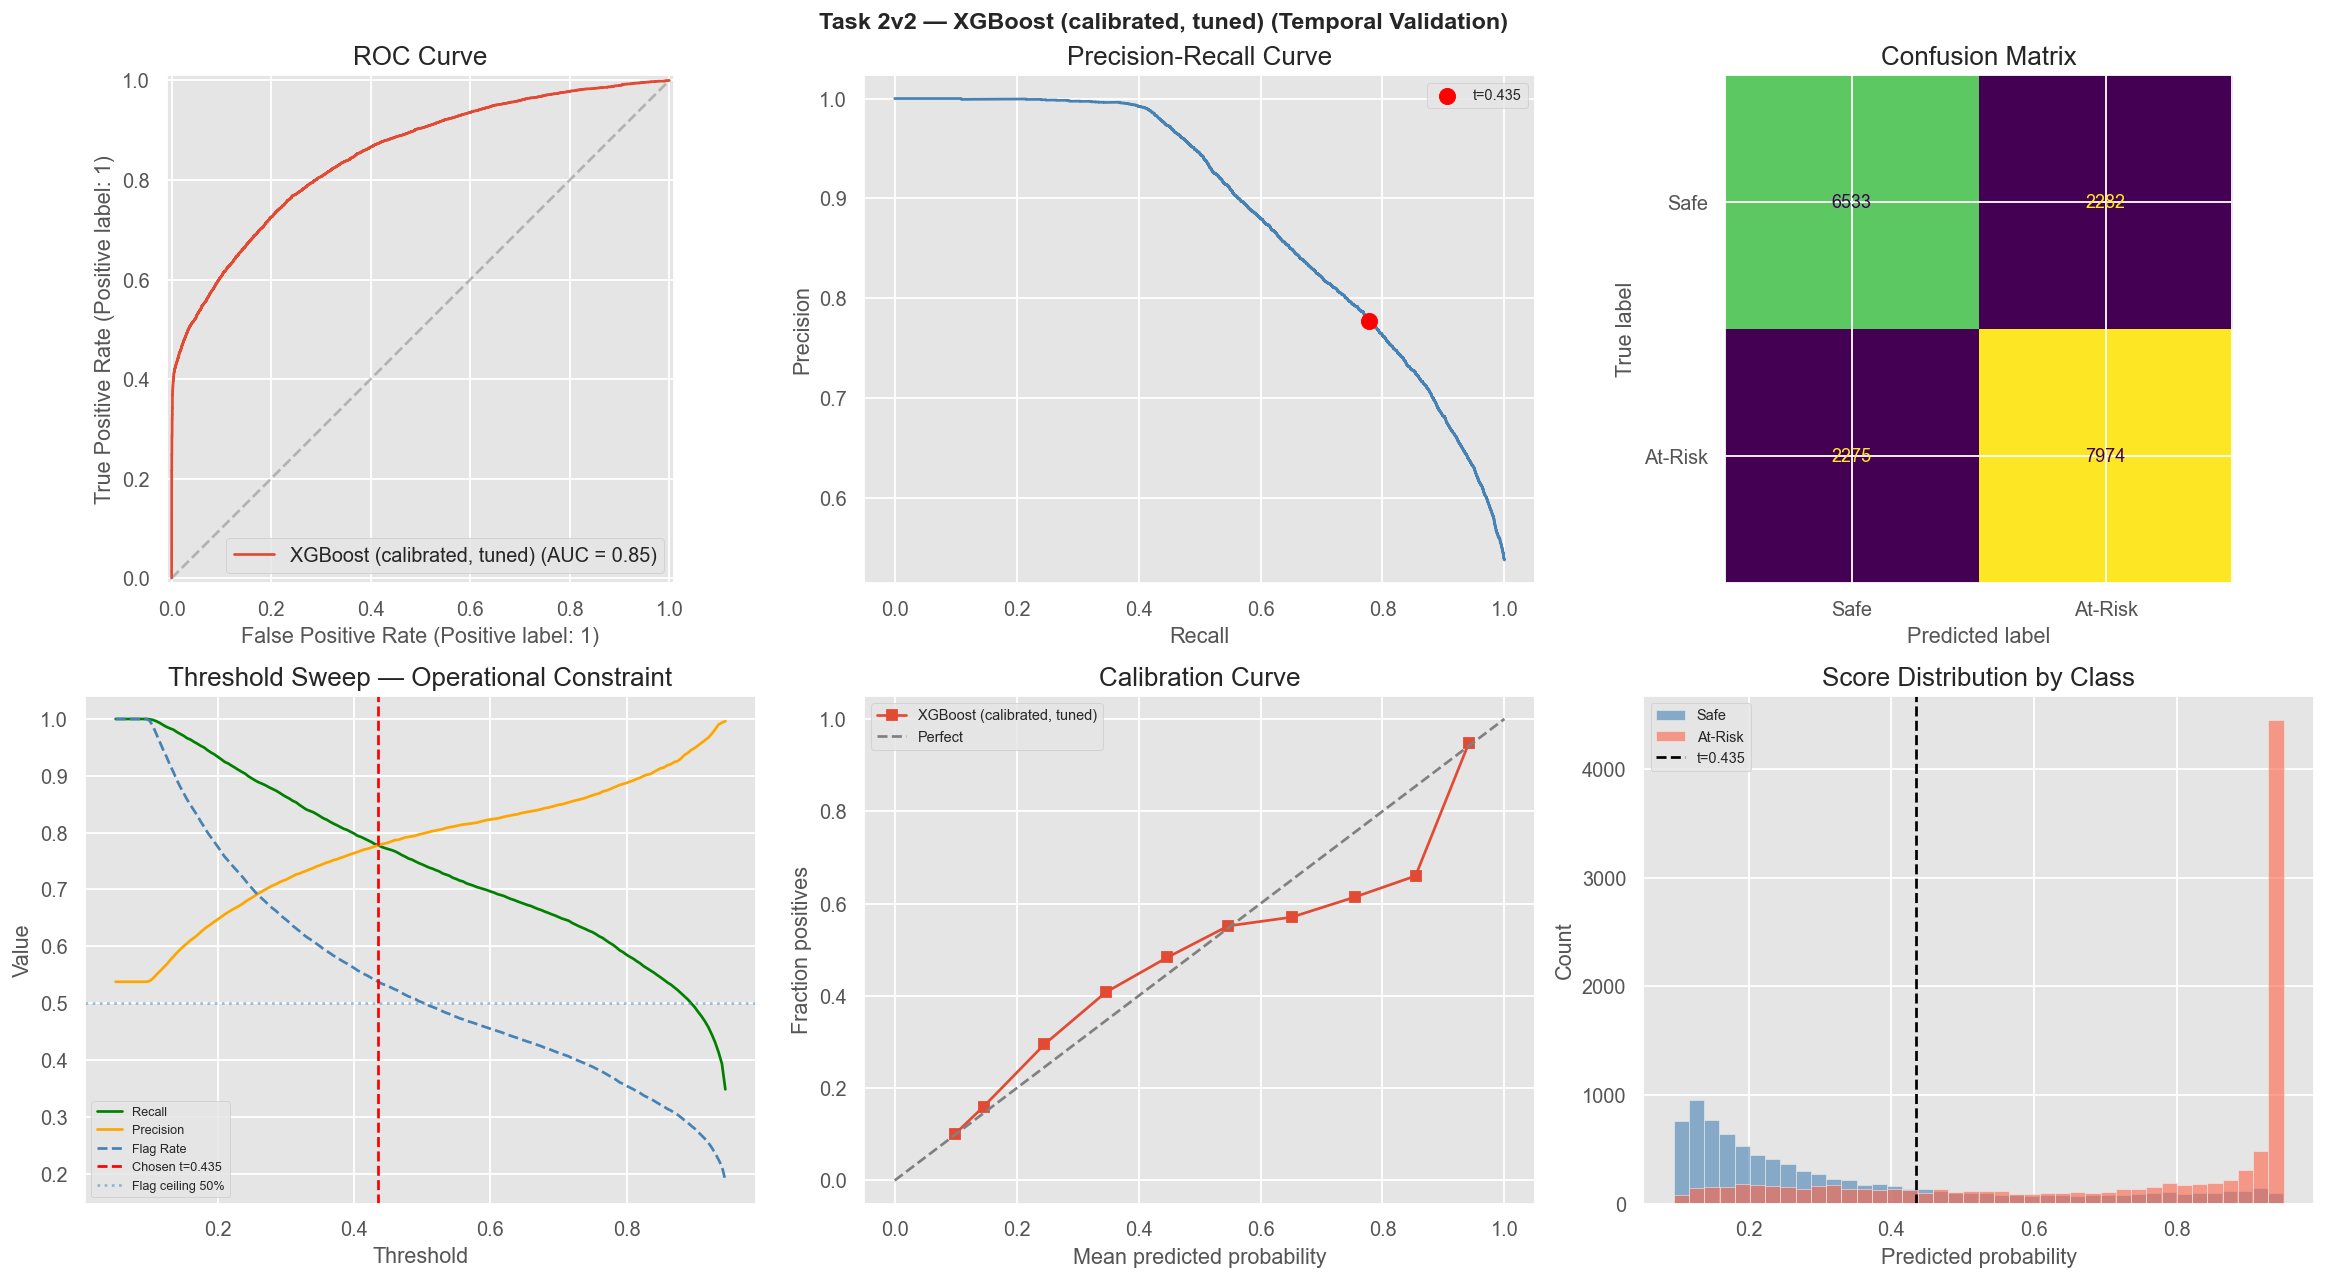

Saved: PLOTS/eval_xgboost_(calibrated,_tuned).png


In [8]:
metrics, test_probs = evaluate(
    cal_model, X_te, y_te, best_threshold,
    feat_cols, label='XGBoost (calibrated, tuned)', output_dir='PLOTS'
)

## Stage 8 — Per-Module AUROC


Per-module AUROC:
module    n  pct_atrisk    auroc   recall  precision  flag_rate
   GGG 1582    0.417193 0.713642 0.593939   0.588589   0.420986
   AAA  365    0.306849 0.755541 0.571429   0.542373   0.323288
   BBB 3905    0.518822 0.828104 0.738401   0.726566   0.527273
   CCC 4434    0.621561 0.859331 0.885341   0.786843   0.699369
   FFF 3865    0.541785 0.864839 0.773161   0.801485   0.522639
   DDD 3031    0.580666 0.879059 0.779545   0.845348   0.535467
   EEE 1882    0.446865 0.894704 0.702735   0.883408   0.355473


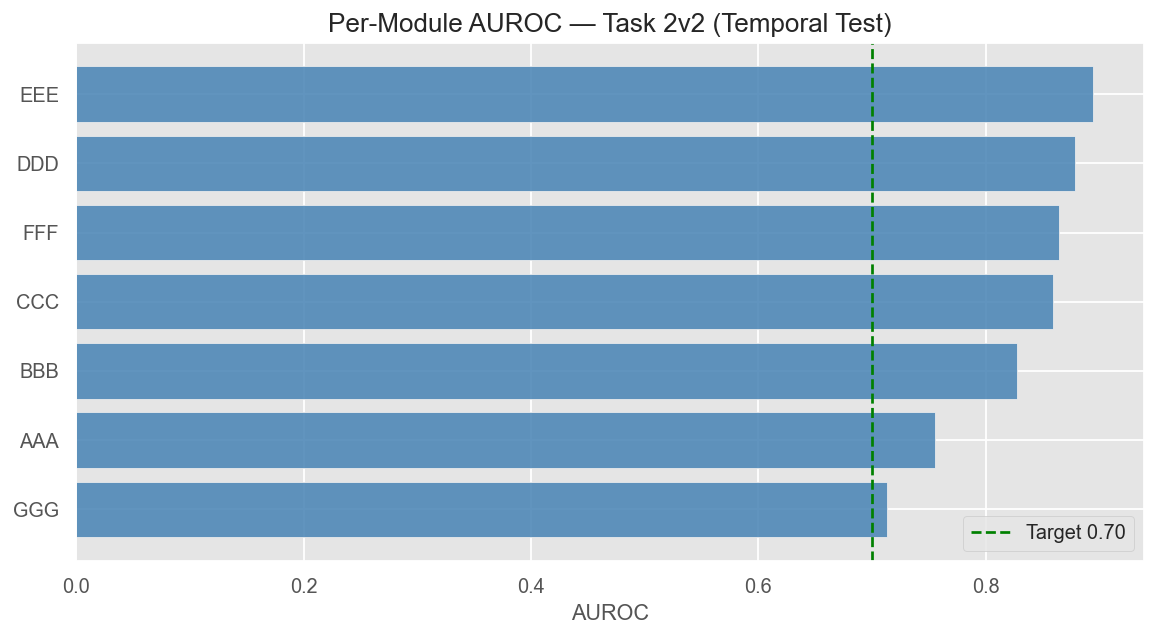

In [9]:
mod_df = per_module_metrics(cal_model, df_test.copy(), feat_cols, best_threshold, output_dir='PLOTS')

## Stage 9 — SHAP Feature Importance

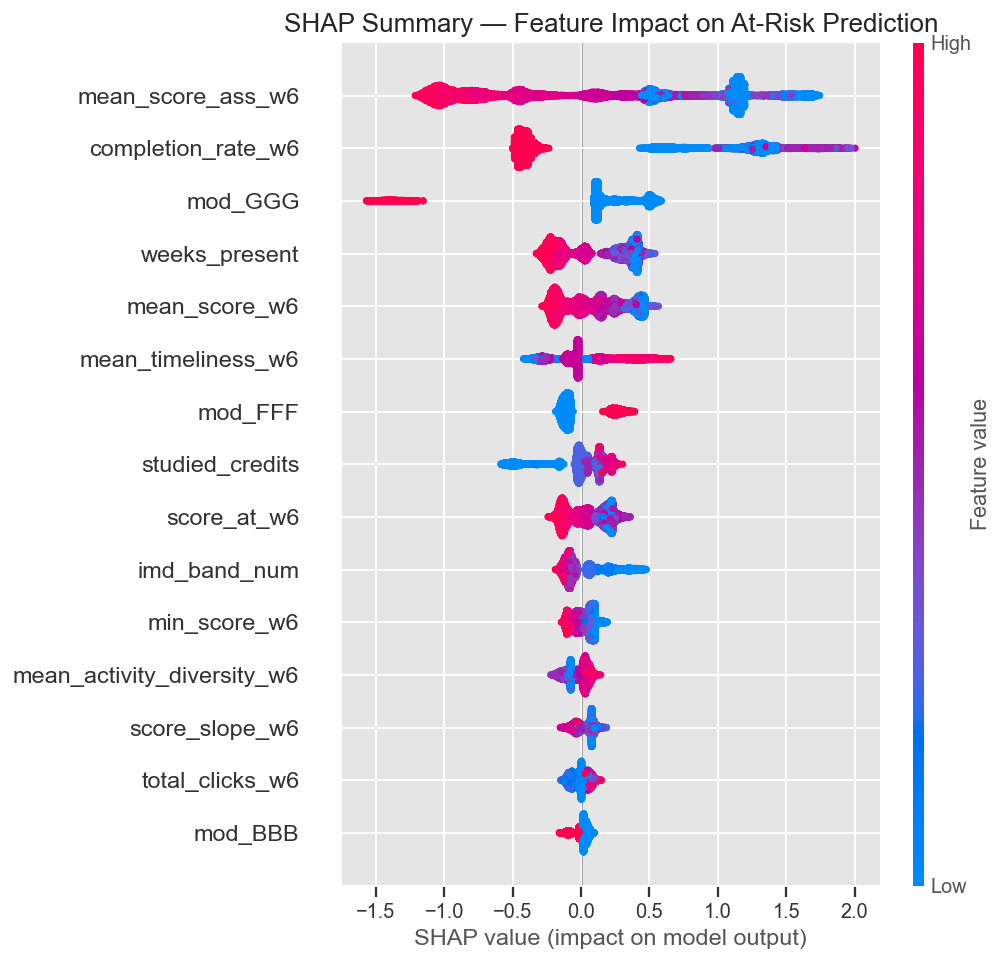

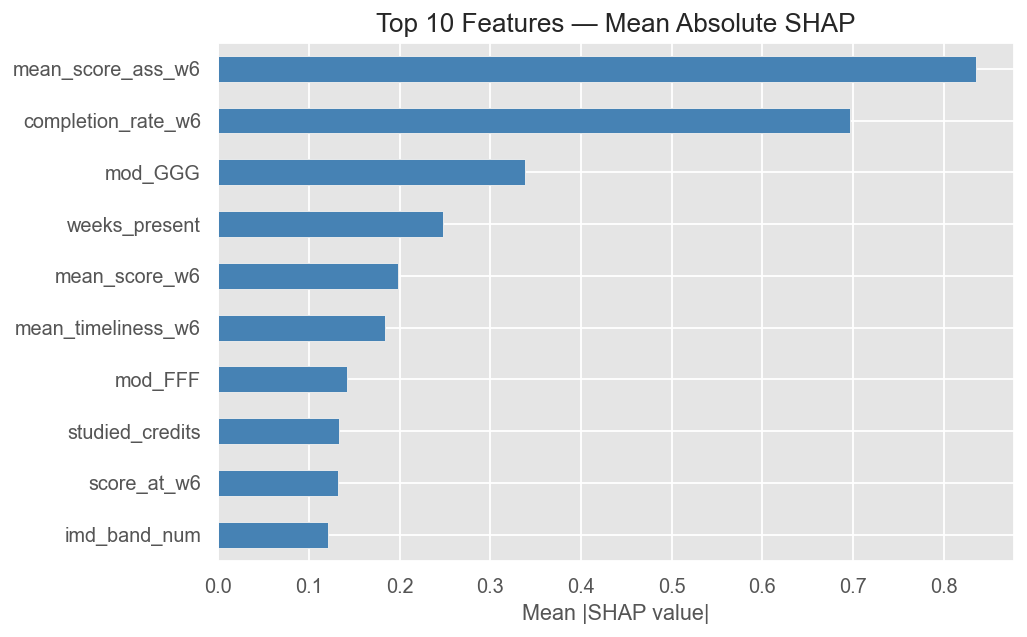


Top 3 features (SHAP):
  mean_score_ass_w6: 0.8355
  completion_rate_w6: 0.6966
  mod_GGG: 0.3379


In [10]:
explainer, shap_values = shap_analysis(tuned_model, X_tr, X_te, feat_cols, output_dir='PLOTS')

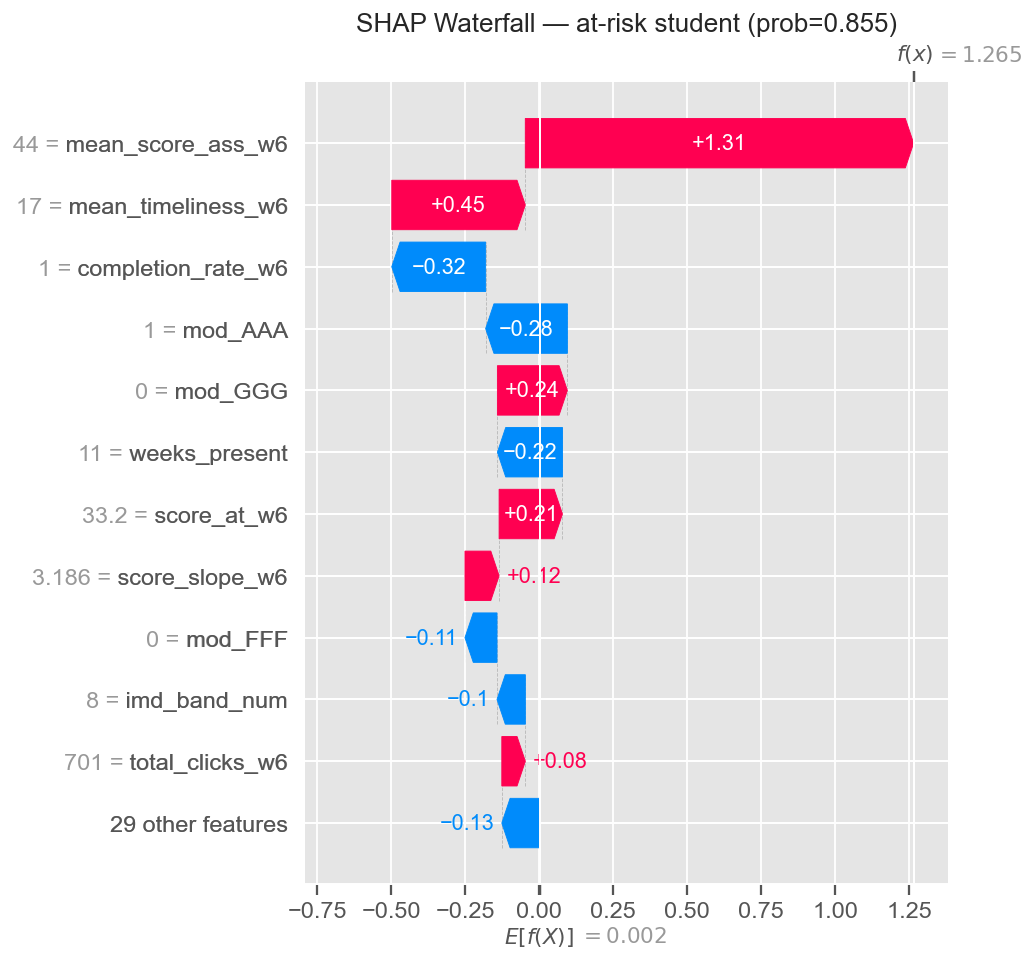

Saved: PLOTS/shap_waterfall_at-risk.png


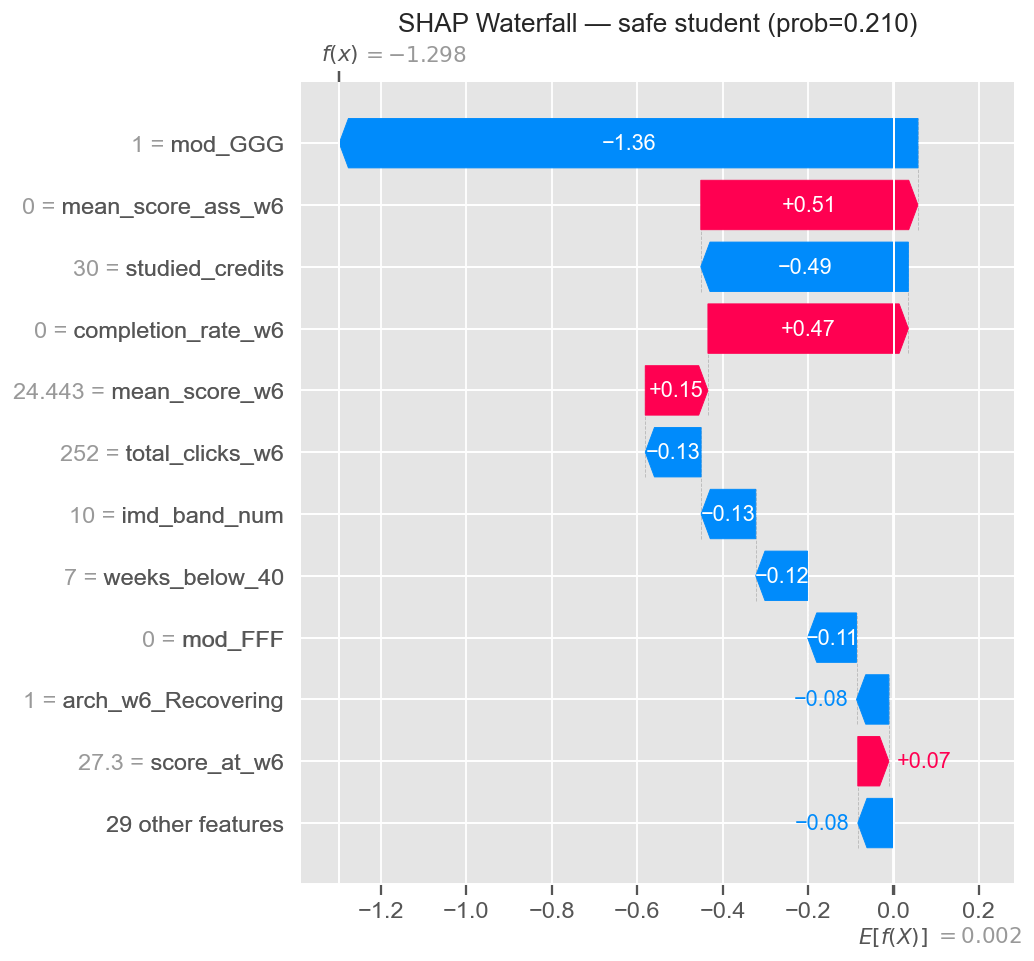

Saved: PLOTS/shap_waterfall_safe.png


In [11]:
shap_waterfall(explainer, shap_values, X_te, y_te, test_probs, feat_cols, best_threshold, output_dir='PLOTS')

## Stage 10 — Staff Alert Table

In [12]:
alerts = build_alerts(cal_model, df_test.copy(), feat_cols, best_threshold, shap_values, output_dir='OUTPUTS')
display_cols = ['id_student', 'code_module', 'risk_prob', 'alert_tier']
if 'archetype_at_w6' in alerts.columns:
    display_cols.append('archetype_at_w6')
display_cols += ['top3_reasons', 'recommended_action']
print('\nSample alerts (top 10 highest risk):')
print(alerts[display_cols].head(10).to_string(index=False))


Staff Alert Summary:
  Total students:  19,064
  Flagged:         10,256 (53.8%)
  High:            8,201
  Medium:          2,055
  Watch:           8,808
  Saved: OUTPUTS/student_alerts_v2.csv

Sample alerts (top 10 highest risk):
 id_student code_module  risk_prob alert_tier archetype_at_w6                                                             top3_reasons                                    recommended_action
    2687012         FFF       0.95       High           Ghost completion_rate_w6 (↑risk) | mean_score_ass_w6 (↑risk) | mod_GGG (↑risk) Immediate outreach — schedule meeting within 48 hours
    1895399         FFF       0.95       High           Ghost completion_rate_w6 (↑risk) | mean_score_ass_w6 (↑risk) | mod_GGG (↑risk) Immediate outreach — schedule meeting within 48 hours
    1972368         FFF       0.95       High           Ghost completion_rate_w6 (↑risk) | mean_score_ass_w6 (↑risk) | mod_GGG (↑risk) Immediate outreach — schedule meeting within 48 hours
    207167

## Stage 11 — Summary

In [13]:
print('=' * 65)
print('TASK 2v2 — SUMMARY (tuned model, 50% flag rate ceiling)')
print('=' * 65)
print(f'Train presentations : 2013J + 2013B  ({len(df_train)+len(df_val):,} students)')
print(f'Test  presentations : 2014J + 2014B  ({len(df_test):,} students)')
print()
print('Final metrics (calibrated XGBoost, temporal test set):')
for k, v in metrics.items():
    print(f'  {k:12s}: {v:.4f}')
print()
print('Before/After comparison (v2 default 35% ceiling vs tuned 50% ceiling):')
print(f'  {"Metric":<12}  {"v2 default (35%)":<22}  {"v2 tuned (50%)"}')
print(f'  {"-"*55}')
v2_default = {"AUROC": 0.8387, "Recall": 0.6433, "Precision": 0.8397, "Flag Rate": 0.4119}
for k in ["AUROC", "Recall", "Precision", "Flag Rate"]:
    old = v2_default[k]
    new = metrics[k]
    arrow = "UP" if new > old else "DOWN"
    print(f'  {k:<12}  {old:<22.4f}  {new:.4f}  ({arrow})')
print()
print('Per-module AUROC range:')
print(f'  Min : {mod_df["auroc"].min():.3f}  ({mod_df.iloc[0]["module"]})')
print(f'  Max : {mod_df["auroc"].max():.3f}  ({mod_df.iloc[-1]["module"]})')
print(f'  Mean: {mod_df["auroc"].mean():.3f}')
print()
print('Best Optuna hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:20s}: {v}')
print()
print('Outputs:')
print('  OUTPUTS/student_alerts_v2.csv')
print('  PLOTS/optuna_history.png')
print('  PLOTS/eval_xgboost_(calibrated,_tuned).png')
print('  PLOTS/threshold_operational.png')
print('  PLOTS/per_module_auroc.png')
print('  PLOTS/shap_summary.png + shap_top10.png + shap_waterfall_*.png')

TASK 2v2 — SUMMARY (tuned model, 50% flag rate ceiling)
Train presentations : 2013J + 2013B  (13,529 students)
Test  presentations : 2014J + 2014B  (19,064 students)

Final metrics (calibrated XGBoost, temporal test set):
  AUROC       : 0.8498
  Recall      : 0.7780
  Precision   : 0.7775
  F1          : 0.7778
  F2          : 0.7779
  Brier       : 0.1624
  Flag Rate   : 0.5380
  Threshold   : 0.4350

Before/After comparison (v2 default 35% ceiling vs tuned 50% ceiling):
  Metric        v2 default (35%)        v2 tuned (50%)
  -------------------------------------------------------
  AUROC         0.8387                  0.8498  (UP)
  Recall        0.6433                  0.7780  (UP)
  Precision     0.8397                  0.7775  (DOWN)
  Flag Rate     0.4119                  0.5380  (UP)

Per-module AUROC range:
  Min : 0.714  (GGG)
  Max : 0.895  (EEE)
  Mean: 0.828

Best Optuna hyperparameters:
  n_estimators        : 699
  learning_rate       : 0.016072582517400815
  max_depth